In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [4]:
test_ids = test_df['id'].copy()
train_ids = train_df['id'].copy()

In [5]:
for df in [test_df, train_df]:
    df.drop(columns=['id'], inplace=True)

In [6]:
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [8]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
train_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
test_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

/tmp/ipykernel_17/1059236750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='summer')


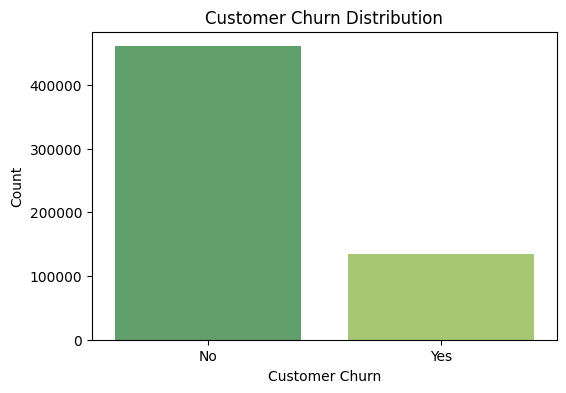

In [11]:
# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=train_df, palette='summer')
plt.title('Customer Churn Distribution')
plt.xlabel('Customer Churn')
plt.ylabel('Count')
plt.show()

In [12]:
cat_cols = [
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod'
]

train_df = pd.get_dummies(train_df, columns=cat_cols)
test_df = pd.get_dummies(test_df, columns=cat_cols)

In [13]:
# Encodar el objetico con map
y = train_df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
#verificar desbalance
print(y.value_counts())
print("\nProporción:")
print(y.value_counts(normalize=True))

Churn
0    460377
1    133817
Name: count, dtype: int64

Proporción:
Churn
0    0.774792
1    0.225208
Name: proportion, dtype: float64


In [15]:
# Calcular scale_pos_weight
scale_pos_weight = len(y[y == 0]) / len(y[y == 1])
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")


scale_pos_weight: 3.44


In [16]:
# Create Dataset for Training
X = train_df.drop('Churn', axis=1)

# Reordenar el test para que las columnas estén ordenadas con el index
test_df = test_df.reindex(
    columns=X.columns,
    fill_value=0
)

In [17]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
XGB_PARAMS = {
    'n_estimators'         : 10000,
    'learning_rate'        : 0.01,
    'max_depth'            : 6,
    'subsample'            : 0.8,
    'colsample_bytree'     : 0.8,
    'tree_method'          : 'hist',
    'device'               : 'cuda',
    'eval_metric'          : 'auc',
    'early_stopping_rounds': 200,
    'random_state'         : 42,
    'verbosity'            : 0,
    'scale_pos_weight'     : scale_pos_weight,
}

In [19]:
scores = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model = XGBClassifier(**XGB_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    best_iterations.append(model.best_iteration)
    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    scores.append(auc)
    acc = accuracy_score(y_val, model.predict(X_val))
    print(f"Fold AUC: {auc:.4f} | ACC: {acc:.4f} | Best iter: {model.best_iteration}")

print("\nMean CV AUC:", np.mean(scores))
print("Mean best iteration:", int(np.mean(best_iterations)))


Fold 1
Fold AUC: 0.9160 | ACC: 0.8208 | Best iter: 3089

Fold 2
Fold AUC: 0.9171 | ACC: 0.8189 | Best iter: 3359

Fold 3
Fold AUC: 0.9165 | ACC: 0.8202 | Best iter: 3473

Fold 4
Fold AUC: 0.9175 | ACC: 0.8224 | Best iter: 3237

Fold 5
Fold AUC: 0.9148 | ACC: 0.8186 | Best iter: 3093

Mean CV AUC: 0.9163792002706461
Mean best iteration: 3250


In [20]:
FINAL_PARAMS = XGB_PARAMS.copy()
FINAL_PARAMS.pop('early_stopping_rounds')
FINAL_PARAMS['n_estimators'] = int(np.mean(best_iterations))

In [21]:
final_model = XGBClassifier(**FINAL_PARAMS)
final_model.fit(X, y, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=3250,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
y_test_pred = final_model.predict_proba(test_df)[:, 1]

In [23]:
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': y_test_pred 
})

submission.to_csv('submission.csv', index=False)
